In [82]:
import pandas as pd
import numpy as np

df = pd.read_csv('HousingData.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


1. CRIM - per capita crime rate by town
2. ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
3. INDUS - proportion of non-retail business acres per town.
4. CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5. NOX - nitric oxides concentration (parts per 10 million)
6. RM - average number of rooms per dwelling
7. AGE - proportion of owner-occupied units built prior to 1940
8. DIS - weighted distances to five Boston employment centres
9. RAD - index of accessibility to radial highways
10. TAX - full-value property-tax rate per 10,000 (dollars)
11. PTRATIO - pupil-teacher ratio by town
12. B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13. LSTAT - % lower status of the population
14. MEDV - Median value of owner-occupied homes in 1000's (dollars)

# Пайплайн
1. Очистка данных
2. Обучение модели
3. Оценка

### 1. Очистка данных
1. Проверка на NaN
2. Удаление дубликатов
3. Обработка типов данных
4. Поиск и обработка аномалий

### 1.1 NaN

In [68]:
# Проверка на пропуски
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [69]:
# Заполнение пропусков средним значением
df = df.fillna(df.median())
# Пропуски после обработки
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


### 1.2. Дубликаты

In [70]:
# Проверка на наличие полных копий строк
duplicates = df.duplicated().sum()
# Найденные дубликаты
print(duplicates)

0


### 1.3. Преобразование типов данных

In [71]:
# Какие типы данных есть
print(df.dtypes)

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object


### 1.4. Удаление аномалий

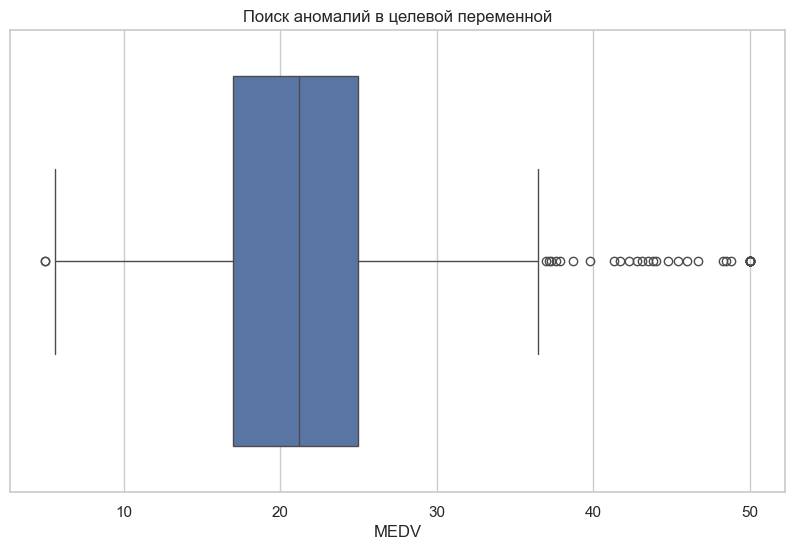

In [72]:
# Для более понятного представление лучше исопльзовать визуализацию
import seaborn as sns
import matplotlib.pyplot as plt

# График для целевой переменной (MEDV - средняя цена в тыс. долларов)
sns.boxplot(x=df['MEDV'])
plt.title('Поиск аномалий в целевой переменной')
plt.show()

In [73]:
# Центральная линия - медиана (половина меньше нее, половина больше)
# Границы прямоугольника - 25-й и 75-й процентили (внутри него половина всех домов)
# Две вертикальные линии обозначают границы отрезка, все что вне него - аномалии
# Маленькие окружности и есть аномалии (или выбросы)

<Axes: xlabel='MEDV'>

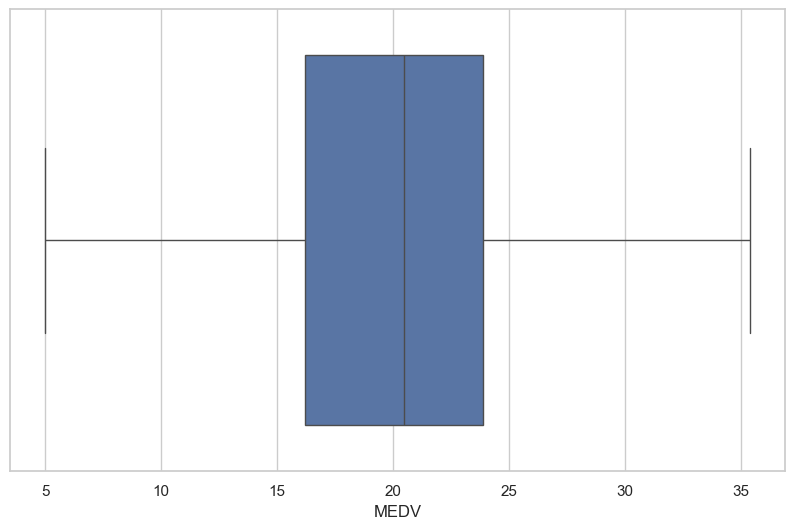

In [74]:
# Оставляем только нормальные знаачения, которые внутри отрезка
df_clean = df[df['MEDV'] < 36]

# Визуализация после чистки
sns.boxplot(x=df_clean['MEDV'])

## 2. Обучение модели
1. Разделение на признаки и цель
2. Разбиение на обучающую выборку и тестовую выборку
3. Выбор алгоритма и обучение

In [75]:
# Признаки (все колонки, кроме цены)
X = df.drop('MEDV', axis=1) 

# Целевая переменная (цена дома)
y = df['MEDV']

In [76]:
from sklearn.model_selection import train_test_split

# test_size=0.2 означает, что 20% данных пойдет на проверку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
from sklearn.linear_model import LinearRegression

# Создаем экземпляр модели
model = LinearRegression()

# Обучаем модель на тренировочных данных
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 3. Оценка

In [78]:
from sklearn.metrics import mean_absolute_error

# Получаем предсказания
predictions = model.predict(X_test)

# Считаем среднюю ошибку (в тыс. долларов)
mae = mean_absolute_error(y_test, predictions)

print(f"Средняя ошибка модели: {mae:.4f} тыс. долларов")

Средняя ошибка модели: 3.1487 тыс. долларов


# Улучшение результата
1. Масштабирование признаков для линейной регрессии
2. Более мощный алгоритм
3. После - сравнение результатов

## 1. Масштабирование признаков

In [79]:
from sklearn.preprocessing import StandardScaler

# Создаем объект масштабирования
scaler = StandardScaler()

# Обучаем скалер на тренировочных данных и трансформируем их
X_train_scaled = scaler.fit_transform(X_train)

# Применяем те же параметры масштабирования к тестовым данным
X_test_scaled = scaler.transform(X_test)

In [80]:
# Обучаем модель на новых данных
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Делаем предсказание на масштабированном тесте
predictions = model.predict(X_test_scaled)

# Оцениваем результат
mae_scaled = mean_absolute_error(y_test, predictions)

print(f"MAE после масштабирования: {mae_scaled:.4f} тыс. долларов")

MAE после масштабирования: 3.1487 тыс. долларов


## 2. Более мощный алгоритм (Random Forest)

In [81]:
from sklearn.ensemble import RandomForestRegressor

# Создаем более мощную модель
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Оцениваем результат
mae_forest = mean_absolute_error(y_test, rf_preds)

print(f"MAE для случайного леса: {mae_forest:.2f} тыс. долларов")

MAE для случайного леса: 2.06 тыс. долларов


## 3. Сравнение

Модель на линейной регрессии дала один и тот же результат (с точностью до 4 знаков после запятой)
что без масштабирования признаков, что с ним.
Использование масштабирования было обоснованно тем, что данные имеют разный масштаб (CRIM может быть 0.00632, а RM может быть 6.575), а линейная регрессия часто работает лучше, когда все данные приведены к одному диапозону.

А вот более мощный алгоритм (случайный лес) показал результат намного лучше, ошибка сократилась почти в треть.
(было 3.15 тыс. долларов, стало 2.06 тыс. долларов)